# EDA Titanic

## 1) Непрерывные признаки 

In [93]:
#Inpor the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [94]:
#Import the dataset
train_df=pd.read_csv('data/train.csv')
train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [95]:
#Drop all categorical features
cat_feat=['PassengerId', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
train_df.drop(cat_feat, axis=1, inplace=True)
train_df.tail()

,Survived,Pclass,Age,SibSp,Parch,Fare
886,0,2,27.0,0,0,13.00
887,1,1,19.0,0,0,30.00
888,0,3,NaN,1,2,23.45
889,1,1,26.0,0,0,30.00
890,0,3,32.0,0,0,7.75


In [96]:
train_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [97]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 41.9 KB


In [98]:
train_df.groupby('Survived').mean()

,Pclass,Age,SibSp,Parch,Fare
Survived,,,,,
0,2.531876,30.626179,0.553734,0.329690,22.117887
1,1.950292,28.343690,0.473684,0.464912,48.395408


In [99]:
train_df.groupby(train_df['Age'].isnull()).mean()

,Survived,Pclass,Age,SibSp,Parch,Fare
Age,,,,,,
False,0.406162,2.236695,29.699118,0.512605,0.431373,34.694514
True,0.293785,2.598870,NaN,0.564972,0.180791,22.158567


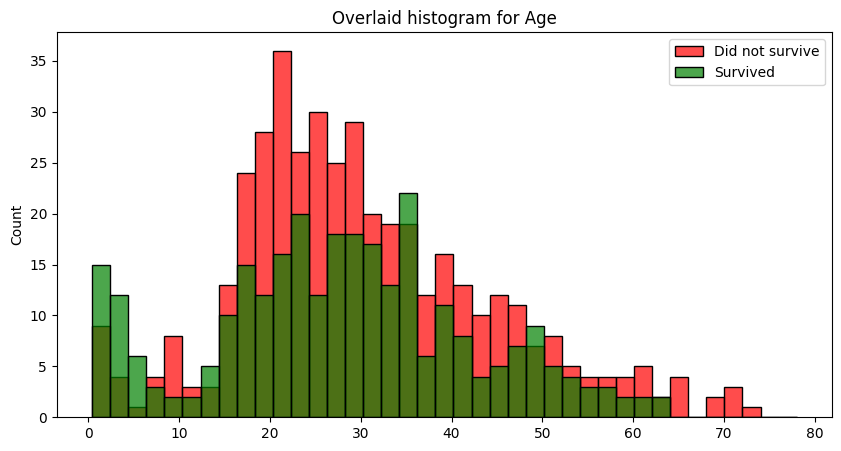

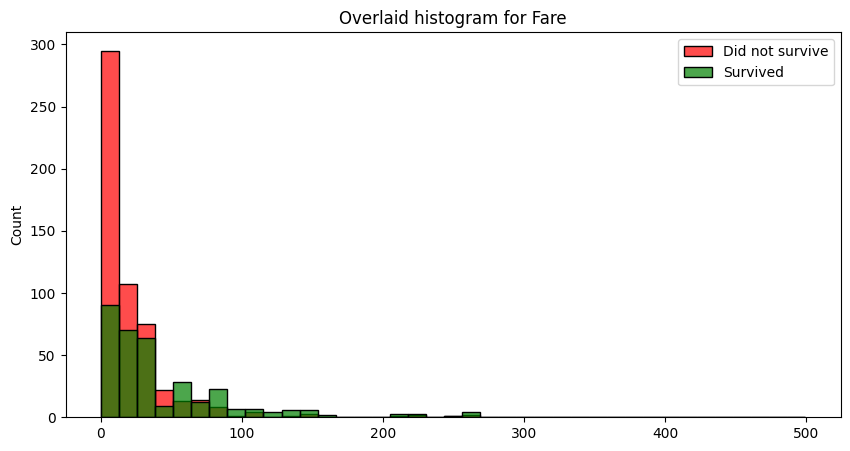

In [100]:
for i in ['Age', 'Fare']:
    died = list(train_df[train_df['Survived'] == 0][i].dropna())
    survived = list(train_df[train_df['Survived'] == 1][i].dropna())
    xmin = min(min(died), min(survived))
    xmax = max(max(died), max(survived))
    width = (xmax - xmin) / 40
    
    plt.figure(figsize=(10, 5))  
    sns.histplot(died, color='r', kde=False, bins=np.arange(xmin, xmax, width), alpha=0.7)
    sns.histplot(survived, color='g', kde=False, bins=np.arange(xmin, xmax, width), alpha=0.7)
    plt.legend(['Did not survive', 'Survived'])
    plt.title('Overlaid histogram for {}'.format(i))
    plt.show()

In [101]:
# Количество пропусков по каждому столбцу
train_df.isnull().sum()


Survived      0
Pclass        0
Age         177
SibSp         0
Parch         0
Fare          0
dtype: int64

## Обоснование выбора медианы для заполнения возраста

1. **Устойчивость к выбросам** — на Титанике есть младенцы (0 лет) и пожилые люди (до 80 лет)

2. **Асимметрия распределения** — больше молодых пассажиров

3. **Реалистичность** —точно отражает типичного пассажира

4. **Сохранение структуры** — заполнение медианой не искажает исходное распределение данных

**Вывод:** медиана — оптимальный выбор для заполнения пропусков в возрасте на Титанике.

In [102]:
train_df.fillna({'Age': train_df['Age'].mean()}, inplace=True)
train_df.head(10)

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.000000,1,0,7.2500
1,1,1,38.000000,1,0,71.2833
2,1,3,26.000000,0,0,7.9250
3,1,1,35.000000,1,0,53.1000
4,0,3,35.000000,0,0,8.0500
5,0,3,29.699118,0,0,8.4583
6,0,1,54.000000,0,0,51.8625
7,0,3,2.000000,3,1,21.0750
8,1,3,27.000000,0,2,11.1333
9,1,2,14.000000,1,0,30.0708


In [103]:
full_duplicates = train_df.duplicated().sum()
print(f"Полных дубликатов строк: {full_duplicates}")

Полных дубликатов строк: 134


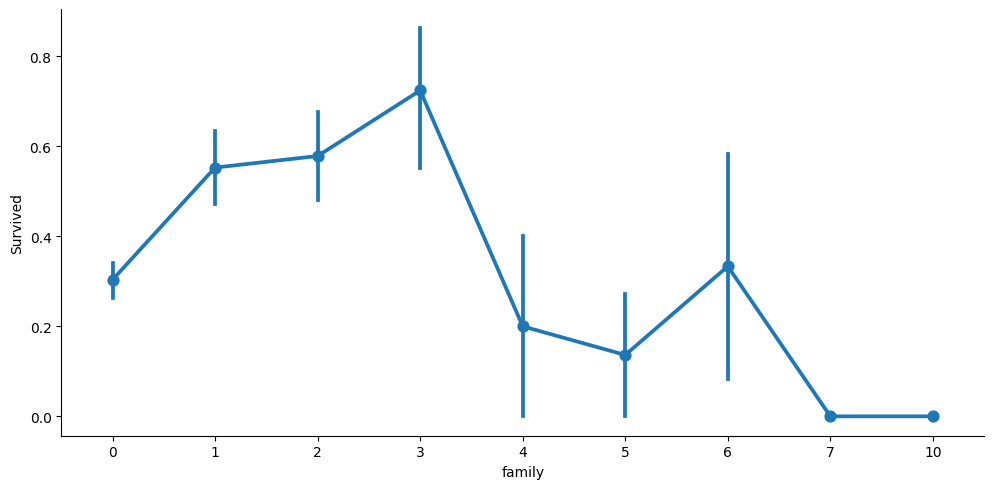

In [104]:
train_df['family']=train_df['SibSp'] + train_df['Parch']
sns.catplot(x='family', y='Survived', data=train_df, kind='point',aspect=2,)

In [105]:
train_df.drop(['SibSp','Parch'], axis=1, inplace=True)

In [106]:
train_df.head()

,Survived,Pclass,Age,Fare,family
0,0,3,22.0,7.2500,1
1,1,1,38.0,71.2833,1
2,1,3,26.0,7.9250,0
3,1,1,35.0,53.1000,1
4,0,3,35.0,8.0500,0


In [107]:
num_cols = train_df.select_dtypes(include=['number'])
stats = num_cols.describe(percentiles=[.05, .25, .50, .75, .95])

# 2. Добавляем медиану, моду, дисперсию, асимметрию и эксцесс
# Мода (берем первое значение, так как их может быть несколько)
stats.loc['median'] = num_cols.median()
stats.loc['mode'] = num_cols.mode().iloc[0] 
stats.loc['var'] = num_cols.var()
stats.loc['skew'] = num_cols.skew()
stats.loc['kurt'] = num_cols.kurt()

print(stats)


          Survived      Pclass         Age         Fare      family
count   891.000000  891.000000  891.000000   891.000000  891.000000
mean      0.383838    2.308642   29.699118    32.204208    0.904602
std       0.486592    0.836071   13.002015    49.693429    1.613459
min       0.000000    1.000000    0.420000     0.000000    0.000000
5%        0.000000    1.000000    6.000000     7.225000    0.000000
25%       0.000000    2.000000   22.000000     7.910400    0.000000
50%       0.000000    3.000000   29.699118    14.454200    0.000000
75%       1.000000    3.000000   35.000000    31.000000    1.000000
95%       1.000000    3.000000   54.000000   112.079150    5.000000
max       1.000000    3.000000   80.000000   512.329200   10.000000
median    0.000000    3.000000   29.699118    14.454200    0.000000
mode      0.000000    3.000000   29.699118     8.050000    0.000000
var       0.236772    0.699015  169.052400  2469.436846    2.603248
skew      0.478523   -0.630548    0.434488     4

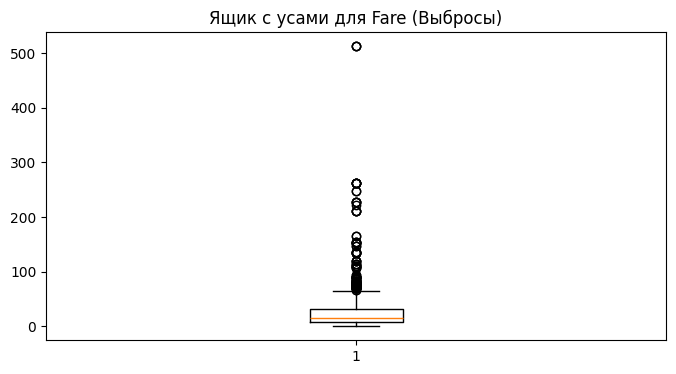

In [108]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['fare'].dropna())
plt.title('Ящик с усами для Fare (Выбросы)')
plt.show()

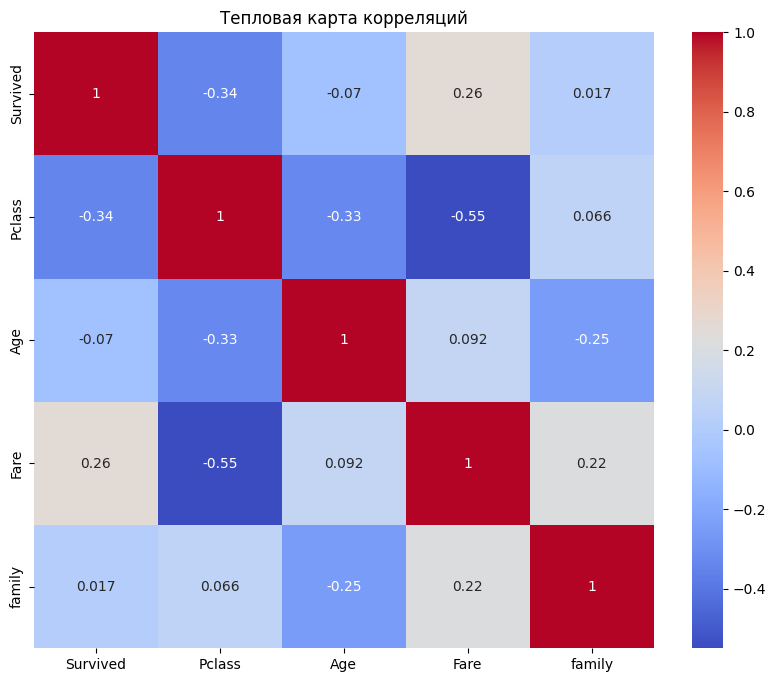

In [109]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Тепловая карта корреляций')
plt.show()

## 2) Категориальные признаки 

In [110]:
train_df=pd.read_csv('data/train.csv')
con_features=['PassengerId', 'Pclass', 'Name','Age', 'SibSp', 'Parch', 'Fare', 'family']
train_df.drop(con_features, axis=1, inplace=True, errors='ignore')
train_df.head()

,Survived,Sex,Ticket,Cabin,Embarked
0,0,male,A/5 21171,NaN,S
1,1,female,PC 17599,C85,C
2,1,female,STON/O2. 3101282,NaN,S
3,1,female,113803,C123,S
4,0,male,373450,NaN,S


In [111]:
train_df.groupby(train_df['Cabin'].isnull()).mean(numeric_only=True)

,Survived
Cabin,
False,0.666667
True,0.299854


In [112]:
train_df['Cabin_indicator']=np.where(train_df['Cabin'].isnull(), 0,1)
train_df.head(10)

,Survived,Sex,Ticket,Cabin,Embarked,Cabin_indicator
0,0,male,A/5 21171,NaN,S,0
1,1,female,PC 17599,C85,C,1
2,1,female,STON/O2. 3101282,NaN,S,0
3,1,female,113803,C123,S,1
4,0,male,373450,NaN,S,0
5,0,male,330877,NaN,Q,0
6,0,male,17463,E46,S,1
7,0,male,349909,NaN,S,0
8,1,female,347742,NaN,S,0
9,1,female,237736,NaN,C,0


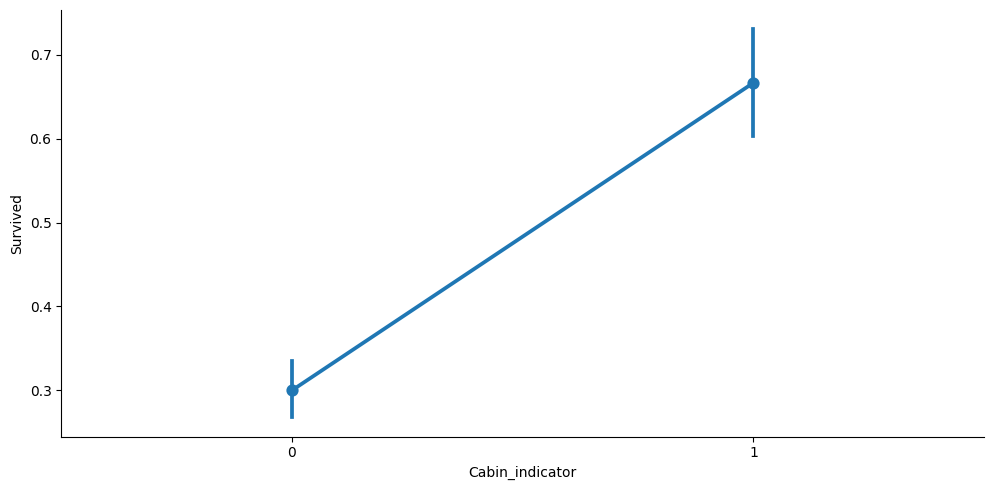

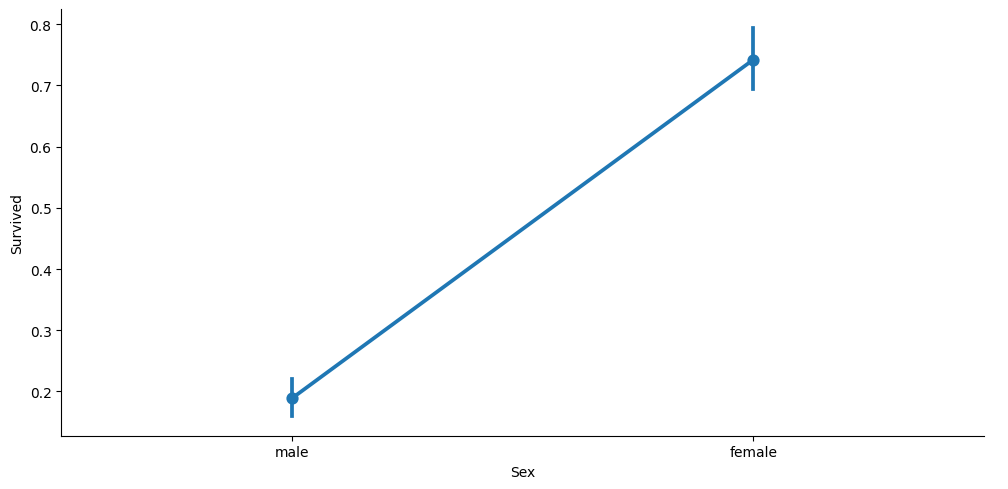

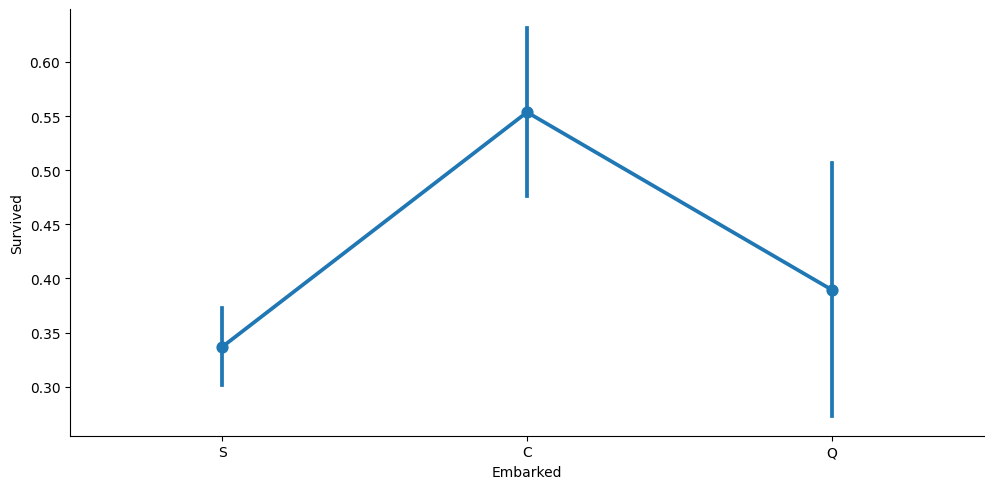

In [113]:
for i, col in enumerate(['Cabin_indicator', 'Sex', 'Embarked']):
    sns.catplot(x=col, y='Survived', data=train_df, kind='point', aspect=2)


In [114]:
train_df.pivot_table('Survived', index='Sex', columns='Embarked', aggfunc='count')

Embarked,C,Q,S
Sex,,,
female,73,36,203
male,95,41,441


In [115]:
train_df.pivot_table('Survived', index='Cabin_indicator', columns='Embarked', aggfunc='count')

Embarked,C,Q,S
Cabin_indicator,,,
0,99,73,515
1,69,4,129


In [116]:
train_df.drop(['Ticket'], axis=1, inplace=True)
train_df.head()

,Survived,Sex,Cabin,Embarked,Cabin_indicator
0,0,male,NaN,S,0
1,1,female,C85,C,1
2,1,female,NaN,S,0
3,1,female,C123,S,1
4,0,male,NaN,S,0


In [117]:
binary_gender={'male':0, 'female':1}
train_df['Sex']=train_df['Sex'].map(binary_gender)
train_df.head()

,Survived,Sex,Cabin,Embarked,Cabin_indicator
0,0,0,NaN,S,0
1,1,1,C85,C,1
2,1,1,NaN,S,0
3,1,1,C123,S,1
4,0,0,NaN,S,0


## Вывод
При работе с данным датасетом я пришла к выводу, что:
1) Пол решает: Женщины имели значительно более высокий шанс на спасение.
2) Класс важен: Пассажиры 1-го класса выживали чаще, чем 3-го.
Возраст: Дети имели приоритет, что видно по пику выживаемости в районе 0-5 лет.
3) Пропуски: В колонке age много пропусков, которые нужно заполнять медианой по группе.
4) Дисперсия тарифов: Цены на билеты варьируются от 0 до 512, что говорит о колоссальной разнице в условиях.

Гипотезы:
1) Люди, у кого не указан номер каюты было значительтно меньше шансов на спасение.
2) Дорогие билеты: Выбросы в fare — это не ошибки, владельцы почти все спаслись.
3) В порту S село в 4 раза больше мужчин, что обуславливает большую смертность тех пассажиров.

Что бы я делала далее:
Использовала метрику accuracy, recall и percision для решения задачи классификации

Какие подсказки брал у AI и что в итоге проверял/дописывал руками:
Разбирала принцип работ некоторых функций из библиотек, а так же очень помогли обучающие видео на ютубе, поэтому почти всё написано руками и разобрано